# Street Flooding 311 Processing Pipeline

This notebook builds a reproducible processing pipeline for NYC 311 street-flooding complaints.

## Main outputs

1. `data/processed/311/individual_complaints.csv`
2. `data/processed/311/flood_events.csv`

## Core logic

- Download the NYC Open Data Street Flooding dataset: `t9hb-ip2a`
- Read the LION street network from `data/spatial/vector/streets/processed/lion_metrics.gpkg`
- Assign each complaint to a LION `segment_id`
- Use coordinates as the primary matching method
- Use street-name normalization only as a fallback
- Aggregate overlapping complaint intervals into flood events by `segment_id`

In [2]:
from __future__ import annotations

import os
import re
import unicodedata
from datetime import date, timedelta
from pathlib import Path
from typing import Iterable

import geopandas as gpd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sodapy import Socrata

try:
    from IPython.display import display
except ImportError:
    display = print


def find_project_root(start: Path | None = None) -> Path:
    """Return the repository root containing `data/` and `notebooks/`."""
    start = start or Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Project root not found. Run this notebook from inside the repository.")


def ensure_directory(path: Path) -> Path:
    """Create a directory if needed and return it."""
    path.mkdir(parents=True, exist_ok=True)
    return path


ROOT = find_project_root()
CITY_TZ = "America/New_York"

SOURCE_DATASET_ID = "t9hb-ip2a"
DEFAULT_DOMAIN = "data.cityofnewyork.us"
APP_TOKEN = os.getenv("NYC_APP_TOKEN") or os.getenv("SOCRATA_APP_TOKEN")

LION_PATH = ROOT / "data/spatial/vector/streets/processed/lion_metrics.gpkg"

OUTPUT_DIR = ensure_directory(ROOT / "data/processed/311")
CACHE_DIR = ensure_directory(OUTPUT_DIR / "cache")
RAW_CACHE_DIR = ensure_directory(CACHE_DIR / "street_flooding_raw")

INDIVIDUAL_PATH = OUTPUT_DIR / "individual_complaints.csv"
EVENTS_PATH = OUTPUT_DIR / "flood_events.csv"
RAW_MASTER_BASE = CACHE_DIR / "street_flooding_raw_master"

SOURCE_START = "2010-01-01"
SOURCE_END = date.today().isoformat()
MONTHLY_LIMIT = 50_000

MATCH_TOLERANCE_FT = 150.0
HIGH_DISTANCE_FT = 250.0

BOROUGH_CODE_MAP = {
    "1": "MANHATTAN",
    "2": "BRONX",
    "3": "BROOKLYN",
    "4": "QUEENS",
    "5": "STATEN ISLAND",
}

BOROUGH_NORMALIZATION = {
    "MN": "MANHATTAN",
    "MANHATTAN": "MANHATTAN",
    "NEW YORK": "MANHATTAN",
    "NEW YORK COUNTY": "MANHATTAN",
    "KINGS": "BROOKLYN",
    "KINGS COUNTY": "BROOKLYN",
    "BRONX": "BRONX",
    "BRONX COUNTY": "BRONX",
    "BX": "BRONX",
    "BROOKLYN": "BROOKLYN",
    "BK": "BROOKLYN",
    "BKLYN": "BROOKLYN",
    "QUEENS": "QUEENS",
    "QUEENS COUNTY": "QUEENS",
    "QN": "QUEENS",
    "STATEN ISLAND": "STATEN ISLAND",
    "STATEN ISLAND COUNTY": "STATEN ISLAND",
    "SI": "STATEN ISLAND",
    "RICHMOND": "STATEN ISLAND",
    "RICHMOND COUNTY": "STATEN ISLAND",
}

ABBREVIATIONS = [
    ("ST", "STREET"),
    ("AVE", "AVENUE"),
    ("AV", "AVENUE"),
    ("BLVD", "BOULEVARD"),
    ("RD", "ROAD"),
    ("DR", "DRIVE"),
    ("PL", "PLACE"),
    ("LN", "LANE"),
    ("PKWY", "PARKWAY"),
    ("HWY", "HIGHWAY"),
    ("EXPY", "EXPRESSWAY"),
    ("E", "EAST"),
    ("W", "WEST"),
    ("N", "NORTH"),
    ("S", "SOUTH"),
    ("NE", "NORTHEAST"),
    ("NW", "NORTHWEST"),
    ("SE", "SOUTHEAST"),
    ("SW", "SOUTHWEST"),
]

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

print("Project root:", ROOT)
print("Output directory:", OUTPUT_DIR)

Project root: /home/map10194/Documents/urban-flood-stress
Output directory: /home/map10194/Documents/urban-flood-stress/data/processed/311


## Helper functions

These functions handle Socrata downloads, timestamp parsing, text normalization, and cache management.

In [3]:
def month_ranges(start: str, end: str):
    """Yield calendar-month windows between two ISO dates."""
    start_dt = pd.Timestamp(start).date()
    end_dt = pd.Timestamp(end).date()
    cursor = start_dt

    while cursor <= end_dt:
        if cursor.month == 12:
            next_month = date(cursor.year + 1, 1, 1)
        else:
            next_month = date(cursor.year, cursor.month + 1, 1)

        chunk_end = min(next_month, end_dt + timedelta(days=1))
        yield cursor.isoformat(), chunk_end.isoformat(), cursor.strftime("%Y_%m")
        cursor = next_month


def query_socrata_rows(
    client: Socrata,
    dataset_id: str,
    *,
    select: str | None = None,
    where: str | None = None,
    order: str | None = None,
    limit: int = MONTHLY_LIMIT,
) -> pd.DataFrame:
    """Fetch a Socrata query in stable pages."""
    rows: list[dict] = []
    offset = 0

    while True:
        query: dict[str, object] = {"limit": limit, "offset": offset}
        if select is not None:
            query["select"] = select
        if where is not None:
            query["where"] = where
        if order is not None:
            query["order"] = order

        batch = client.get(dataset_id, **query)
        if not batch:
            break

        rows.extend(batch)

        if len(batch) < limit:
            break

        offset += limit

    return pd.DataFrame.from_records(rows)


def resolve_field(available: Iterable[str], *candidates: str) -> str | None:
    """Return the first available field name from a list of candidates."""
    available_list = [str(col) for col in available]
    available_set = set(available_list)
    available_lower = {str(col).lower(): str(col) for col in available_list}

    for candidate in candidates:
        if candidate in available_set:
            return candidate

        lowered = candidate.lower()
        if lowered in available_lower:
            return available_lower[lowered]

    return None


def infer_field_map(available: Iterable[str], source_id: str | None = None) -> dict[str, str | None]:
    """Infer source field names from available columns."""
    available = list(available)

    return {
        "source_id": source_id,
        "created": resolve_field(available, "created_date", "created", "date_created", "open_date", "date"),
        "unique": resolve_field(available, "unique_key", "id", "complaint_id", "service_request_id"),
        "closed": resolve_field(available, "closed_date", "resolved_date", "closed", "resolution_date"),
        "status": resolve_field(available, "status", "complaint_status"),
        "borough": resolve_field(available, "borough", "boro"),
        "complaint": resolve_field(available, "complaint_type", "complaint"),
        "descriptor": resolve_field(available, "descriptor", "description"),
        "street": resolve_field(available, "street_name", "street", "incident_address"),
        "latitude": resolve_field(available, "latitude", "lat"),
        "longitude": resolve_field(available, "longitude", "lon", "lng"),
        "x": resolve_field(available, "x_coordinate_state_plane", "x_coordinate", "x"),
        "y": resolve_field(available, "y_coordinate_state_plane", "y_coordinate", "y"),
        "incident_zip": resolve_field(available, "incident_zip", "zip"),
        "location": resolve_field(available, "location"),
    }


def cached_frame_path(base: Path) -> Path | None:
    """Return an existing parquet or CSV cache path."""
    parquet = base.with_suffix(".parquet")
    csv = base.with_suffix(".csv")

    if parquet.exists():
        return parquet

    if csv.exists():
        return csv

    return None


def write_cached_frame(frame: pd.DataFrame, base: Path) -> Path:
    """Persist a frame as parquet when available, otherwise CSV."""
    try:
        path = base.with_suffix(".parquet")
        frame.to_parquet(path, index=False)
        return path
    except Exception:
        path = base.with_suffix(".csv")
        frame.to_csv(path, index=False)
        return path


def read_cached_frame(path: Path) -> pd.DataFrame:
    """Read a cached frame from parquet or CSV."""
    if path.suffix == ".parquet":
        return pd.read_parquet(path)

    return pd.read_csv(path, low_memory=False)


def build_street_flood_where(complaint_field: str | None, descriptor_field: str | None) -> str | None:
    """Build a permissive street-flooding filter using text fields."""
    clauses = []

    for field in [complaint_field, descriptor_field]:
        if not field:
            continue

        expr = f"upper(coalesce(`{field}`, ''))"
        clauses.append(
            "("
            + " OR ".join(
                [
                    f"{expr} LIKE '%STREET FLOOD%'",
                    f"{expr} LIKE '%FLOODED STREET%'",
                    f"{expr} LIKE '%FLOOD%STREET%'",
                    f"{expr} LIKE '%INUND%CALLE%'",
                    f"{expr} LIKE '%CALLE%INUND%'",
                ]
            )
            + ")"
        )

    if not clauses:
        return None

    return " OR ".join(clauses)


def build_order_clause(created_field: str, unique_field: str | None) -> str:
    """Return a stable order clause for paging."""
    if unique_field:
        return f"`{created_field}` ASC, `{unique_field}` ASC"

    return f"`{created_field}` ASC"


def parse_timestamp_series(series: pd.Series) -> pd.Series:
    """Parse timestamps and convert them to New York local time."""
    return pd.to_datetime(series, errors="coerce", utc=True).dt.tz_convert(CITY_TZ)


def clean_text(value):
    """Normalize text for street and borough matching."""
    if value is None or pd.isna(value):
        return pd.NA

    text = unicodedata.normalize("NFKD", str(value))
    text = text.encode("ascii", "ignore").decode("ascii")
    text = text.upper().strip()
    text = text.replace("&", " AND ")
    text = re.sub(r"[\.,;/_@\-]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    if not text:
        return pd.NA

    parts = text.split()

    if len(parts) >= 3 and re.fullmatch(r"[\d\-]+", parts[0]):
        text = " ".join(parts[1:])

    for abbr, full in ABBREVIATIONS:
        text = re.sub(rf"\b{re.escape(abbr)}\b", full, text)

    text = re.sub(r"\s+", " ", text).strip()
    return text or pd.NA


def normalize_borough(value):
    """Normalize borough names to a canonical NYC form."""
    text = clean_text(value)

    if pd.isna(text):
        return pd.NA

    return BOROUGH_NORMALIZATION.get(str(text), str(text))


def first_nonempty(frame: pd.DataFrame, columns: list[str]) -> pd.Series:
    """Return the first non-empty string across candidate columns."""
    out = pd.Series(pd.NA, index=frame.index, dtype="string")

    for column in columns:
        if column in frame.columns:
            series = frame[column].astype("string")
            out = out.fillna(series.where(series.str.strip().ne("")))

    return out

## Download the Street Flooding dataset

The pipeline uses `t9hb-ip2a` as the primary and explicit source. It does not prioritize unrelated 311 datasets.

In [4]:
def download_or_load_raw_street_flooding() -> tuple[pd.DataFrame, dict[str, str | None], str]:
    """Download the requested Street Flooding dataset in monthly batches and cache it."""
    master_path = cached_frame_path(RAW_MASTER_BASE)

    if master_path is not None:
        raw = read_cached_frame(master_path)
        source_id = SOURCE_DATASET_ID
        if "source_id" in raw.columns and raw["source_id"].notna().any():
            source_id = raw["source_id"].dropna().astype("string").iloc[0]

        field_map = infer_field_map(raw.columns, source_id)
        raw.attrs["source_id"] = source_id
        raw.attrs["field_map"] = field_map
        return raw, field_map, source_id

    client = Socrata(DEFAULT_DOMAIN, APP_TOKEN, timeout=120)

    sample = client.get(SOURCE_DATASET_ID, limit=1)
    if not sample:
        raise RuntimeError(f"No rows returned from Socrata dataset {SOURCE_DATASET_ID}.")

    field_map = infer_field_map(sample[0].keys(), SOURCE_DATASET_ID)

    created_field = field_map["created"]
    if created_field is None:
        raise RuntimeError(f"No complaint start/open timestamp field found in {SOURCE_DATASET_ID}.")

    unique_field = field_map["unique"]
    closed_field = field_map["closed"]
    status_field = field_map["status"]
    borough_field = field_map["borough"]
    complaint_field = field_map["complaint"]
    descriptor_field = field_map["descriptor"]
    street_field = field_map["street"]
    latitude_field = field_map["latitude"]
    longitude_field = field_map["longitude"]
    x_field = field_map["x"]
    y_field = field_map["y"]
    incident_zip_field = field_map["incident_zip"]
    location_field = field_map["location"]

    select_fields = [
        field
        for field in [
            unique_field,
            created_field,
            closed_field,
            status_field,
            borough_field,
            complaint_field,
            descriptor_field,
            street_field,
            latitude_field,
            longitude_field,
            x_field,
            y_field,
            incident_zip_field,
            location_field,
        ]
        if field
    ]

    select = ",".join(f"`{field}`" for field in dict.fromkeys(select_fields)) if select_fields else None
    order = build_order_clause(created_field, unique_field)
    flood_where = build_street_flood_where(complaint_field, descriptor_field)

    batches: list[pd.DataFrame] = []
    source_cache_dir = ensure_directory(RAW_CACHE_DIR / SOURCE_DATASET_ID)

    for start, end, tag in month_ranges(SOURCE_START, SOURCE_END):
        cache_base = source_cache_dir / f"{SOURCE_DATASET_ID}_{tag}"
        cached_path = cached_frame_path(cache_base)

        if cached_path is not None:
            batches.append(read_cached_frame(cached_path))
            continue

        where_parts = [
            f"`{created_field}` >= '{start}T00:00:00'",
            f"`{created_field}` < '{end}T00:00:00'",
        ]

        if flood_where:
            where_parts.append(f"({flood_where})")

        where = " AND ".join(where_parts)

        frame = query_socrata_rows(
            client,
            SOURCE_DATASET_ID,
            select=select,
            where=where,
            order=order,
            limit=MONTHLY_LIMIT,
        )

        if frame.empty:
            continue

        frame["source_id"] = SOURCE_DATASET_ID
        frame["source_window"] = tag

        write_cached_frame(frame, cache_base)
        batches.append(frame)

    if not batches:
        raise RuntimeError(f"No Street Flooding rows downloaded from {SOURCE_DATASET_ID}.")

    raw = pd.concat(batches, ignore_index=True)

    if unique_field and unique_field in raw.columns:
        raw = raw.drop_duplicates(subset=[unique_field])
    else:
        raw = raw.drop_duplicates()

    raw = raw.reset_index(drop=True)
    raw.attrs["source_id"] = SOURCE_DATASET_ID
    raw.attrs["field_map"] = field_map

    write_cached_frame(raw, RAW_MASTER_BASE)

    return raw, field_map, SOURCE_DATASET_ID

## Build LION lookup tables

The LION GeoPackage is the official segment source. `segment_id` is the primary spatial identifier.

In [5]:
def choose_lion_columns(lion: gpd.GeoDataFrame) -> list[str]:
    """Choose available LION columns needed by the pipeline."""
    candidates = [
        "SegmentID",
        "segment_id",
        "PhysicalID",
        "physicalid",
        "Street",
        "SAFStreetName",
        "LBoro",
        "RBoro",
        "edge_id",
        "geometry",
    ]

    return [col for col in candidates if col in lion.columns]


def build_lion_lookup() -> tuple[gpd.GeoDataFrame, gpd.GeoDataFrame, pd.DataFrame, pd.DataFrame]:
    """Load LION metrics, collapse duplicate segment rows, and build text fallback lookups."""
    lion = gpd.read_file(LION_PATH)
    lion = lion[choose_lion_columns(lion)].copy()

    if "SegmentID" in lion.columns:
        lion["segment_id"] = lion["SegmentID"].astype("string")
    elif "segment_id" in lion.columns:
        lion["segment_id"] = lion["segment_id"].astype("string")
    elif "PhysicalID" in lion.columns:
        lion["segment_id"] = lion["PhysicalID"].astype("string")
    elif "physicalid" in lion.columns:
        lion["segment_id"] = lion["physicalid"].astype("string")
    else:
        raise ValueError("No stable segment identifier found in the LION GeoPackage.")

    if "LBoro" not in lion.columns:
        lion["LBoro"] = pd.NA

    if "RBoro" not in lion.columns:
        lion["RBoro"] = pd.NA

    if "Street" not in lion.columns:
        lion["Street"] = pd.NA

    if "SAFStreetName" not in lion.columns:
        lion["SAFStreetName"] = pd.NA

    if "edge_id" not in lion.columns:
        lion["edge_id"] = lion["segment_id"]

    lion = lion[lion["segment_id"].notna()].copy()

    sort_cols = [col for col in ["edge_id", "segment_id"] if col in lion.columns]
    lion_unique = lion.sort_values(sort_cols).drop_duplicates("segment_id").copy()
    lion_unique = gpd.GeoDataFrame(lion_unique, geometry="geometry", crs=lion.crs)

    print(f"LION rows: {len(lion):,}")
    print(f"Unique segment_id values: {len(lion_unique):,}")
    print(f"Collapsed duplicate rows: {len(lion) - len(lion_unique):,}")
    print(f"LION CRS: {lion_unique.crs}")

    text_candidates = []

    for name_col in ["Street", "SAFStreetName"]:
        if name_col not in lion.columns:
            continue

        temp = lion[["segment_id", "LBoro", "RBoro", name_col]].copy()
        temp["normalized_street_name"] = temp[name_col].map(clean_text)
        temp = temp[temp["normalized_street_name"].notna()].copy()
        temp["borough_left"] = temp["LBoro"].astype("string").map(BOROUGH_CODE_MAP)
        temp["borough_right"] = temp["RBoro"].astype("string").map(BOROUGH_CODE_MAP)

        long = temp.melt(
            id_vars=["segment_id", "normalized_street_name"],
            value_vars=["borough_left", "borough_right"],
            value_name="borough",
        )

        long = long[["segment_id", "normalized_street_name", "borough"]].dropna()
        text_candidates.append(long)

    if text_candidates:
        text_candidates = pd.concat(text_candidates, ignore_index=True).drop_duplicates()
    else:
        text_candidates = pd.DataFrame(columns=["segment_id", "normalized_street_name", "borough"])

    borough_lookup = (
        text_candidates.groupby(["normalized_street_name", "borough"], as_index=False)
        .agg(
            n_segments=("segment_id", "nunique"),
            segment_id=("segment_id", lambda s: s.iloc[0] if s.nunique() == 1 else pd.NA),
        )
    )

    borough_lookup = borough_lookup[borough_lookup["segment_id"].notna()].copy()

    global_lookup = (
        text_candidates.groupby(["normalized_street_name"], as_index=False)
        .agg(
            n_segments=("segment_id", "nunique"),
            segment_id=("segment_id", lambda s: s.iloc[0] if s.nunique() == 1 else pd.NA),
        )
    )

    global_lookup = global_lookup[global_lookup["segment_id"].notna()].copy()

    return lion, lion_unique, borough_lookup, global_lookup

## Complaint geometry and segment matching

Coordinates are the primary source. Nearest-neighbor matching is the main spatial method because complaint points rarely fall exactly on street centerlines.

In [6]:
def extract_point_from_location(value):
    """Try to extract a point from Socrata location dictionaries or strings."""
    if value is None or pd.isna(value):
        return None, None

    if isinstance(value, dict):
        coordinates = value.get("coordinates")
        if coordinates and len(coordinates) >= 2:
            return coordinates[1], coordinates[0]

    text = str(value)
    nums = re.findall(r"-?\d+\.\d+", text)

    if len(nums) >= 2:
        a, b = float(nums[0]), float(nums[1])

        if -90 <= a <= 90 and -180 <= b <= 180:
            return a, b

        if -180 <= a <= 180 and -90 <= b <= 90:
            return b, a

    return None, None


def build_complaint_geometry(
    frame: pd.DataFrame,
    field_map: dict[str, str | None],
    lion_crs,
) -> tuple[pd.DataFrame, dict[str, int]]:
    """Create point geometries from latitude/longitude, location, or state-plane coordinates."""
    out = frame.copy()
    out["geometry"] = None

    coordinate_source = pd.Series(pd.NA, index=out.index, dtype="string")
    has_coordinates = pd.Series(False, index=out.index)

    lat_field = field_map.get("latitude")
    lon_field = field_map.get("longitude")
    location_field = field_map.get("location")
    x_field = field_map.get("x")
    y_field = field_map.get("y")

    out["latitude"] = np.nan
    out["longitude"] = np.nan
    out["x_coordinate_state_plane"] = np.nan
    out["y_coordinate_state_plane"] = np.nan

    if lat_field and lon_field and lat_field in out.columns and lon_field in out.columns:
        lat = pd.to_numeric(out[lat_field], errors="coerce")
        lon = pd.to_numeric(out[lon_field], errors="coerce")
        valid = lat.between(-90, 90) & lon.between(-180, 180)

        if valid.any():
            latlon_gdf = gpd.GeoDataFrame(
                out.loc[valid].copy(),
                geometry=gpd.points_from_xy(lon.loc[valid], lat.loc[valid]),
                crs="EPSG:4326",
            ).to_crs(lion_crs)

            out.loc[valid, "geometry"] = latlon_gdf.geometry.values
            out.loc[valid, "latitude"] = lat.loc[valid]
            out.loc[valid, "longitude"] = lon.loc[valid]
            coordinate_source.loc[valid] = "latlon"
            has_coordinates.loc[valid] = True

    if location_field and location_field in out.columns:
        unresolved = ~has_coordinates

        if unresolved.any():
            parsed = out.loc[unresolved, location_field].map(extract_point_from_location)
            lat = parsed.map(lambda item: item[0] if item else None)
            lon = parsed.map(lambda item: item[1] if item else None)
            lat = pd.to_numeric(lat, errors="coerce")
            lon = pd.to_numeric(lon, errors="coerce")
            valid = lat.between(-90, 90) & lon.between(-180, 180)
            valid_index = lat.index[valid]

            if len(valid_index) > 0:
                location_gdf = gpd.GeoDataFrame(
                    out.loc[valid_index].copy(),
                    geometry=gpd.points_from_xy(lon.loc[valid_index], lat.loc[valid_index]),
                    crs="EPSG:4326",
                ).to_crs(lion_crs)

                out.loc[valid_index, "geometry"] = location_gdf.geometry.values
                out.loc[valid_index, "latitude"] = lat.loc[valid_index]
                out.loc[valid_index, "longitude"] = lon.loc[valid_index]
                coordinate_source.loc[valid_index] = "location"
                has_coordinates.loc[valid_index] = True

    if x_field and y_field and x_field in out.columns and y_field in out.columns:
        unresolved = ~has_coordinates

        if unresolved.any():
            x = pd.to_numeric(out.loc[unresolved, x_field], errors="coerce")
            y = pd.to_numeric(out.loc[unresolved, y_field], errors="coerce")
            valid = x.notna() & y.notna()
            valid_index = x.index[valid]

            if len(valid_index) > 0:
                state_gdf = gpd.GeoDataFrame(
                    out.loc[valid_index].copy(),
                    geometry=gpd.points_from_xy(x.loc[valid_index], y.loc[valid_index]),
                    crs=lion_crs,
                )

                out.loc[valid_index, "geometry"] = state_gdf.geometry.values
                out.loc[valid_index, "x_coordinate_state_plane"] = x.loc[valid_index]
                out.loc[valid_index, "y_coordinate_state_plane"] = y.loc[valid_index]
                coordinate_source.loc[valid_index] = "state_plane"
                has_coordinates.loc[valid_index] = True

    stats = {
        "coordinate_rows": int(has_coordinates.sum()),
        "latlon_rows": int(coordinate_source.eq("latlon").sum()),
        "location_rows": int(coordinate_source.eq("location").sum()),
        "stateplane_rows": int(coordinate_source.eq("state_plane").sum()),
    }

    out["coordinate_source"] = coordinate_source
    out["has_valid_coordinates"] = has_coordinates

    return out, stats


def assign_segment_by_spatial_match(
    complaints: pd.DataFrame,
    lion_unique: gpd.GeoDataFrame,
) -> pd.DataFrame:
    """Assign segment_id using nearest-neighbor spatial matching as the primary method."""
    geo = complaints[complaints["geometry"].notna()].copy()

    if geo.empty:
        return pd.DataFrame(columns=["complaint_id", "segment_id", "match_method", "match_distance"])

    geo = gpd.GeoDataFrame(geo, geometry="geometry", crs=lion_unique.crs)
    lion_basic = lion_unique[["segment_id", "geometry"]].copy()

    nearest = gpd.sjoin_nearest(
        geo,
        lion_basic,
        how="left",
        distance_col="match_distance",
        max_distance=MATCH_TOLERANCE_FT,
    )

    nearest = nearest[["complaint_id", "segment_id", "match_distance"]].copy()
    nearest = nearest.dropna(subset=["segment_id"])
    nearest = nearest.sort_values(["complaint_id", "match_distance"], kind="stable")
    nearest = nearest.drop_duplicates(subset=["complaint_id"], keep="first")
    nearest["match_method"] = "spatial_nearest"

    return nearest[["complaint_id", "segment_id", "match_method", "match_distance"]]


def assign_segment_by_text(
    complaints: pd.DataFrame,
    borough_lookup: pd.DataFrame,
    global_lookup: pd.DataFrame,
) -> pd.DataFrame:
    """Assign segment_id from normalized street names and boroughs as fallback."""
    out = complaints.copy()

    if "borough" in out.columns:
        out["borough"] = out["borough"].astype("string").map(normalize_borough)
    else:
        out["borough"] = pd.NA

    if "normalized_street_name" not in out.columns:
        street_source = first_nonempty(out, ["street_name_raw", "incident_address", "street_name", "descriptor"])
        out["normalized_street_name"] = street_source.map(clean_text)

    borough_join = out.merge(
        borough_lookup[["normalized_street_name", "borough", "segment_id"]],
        on=["normalized_street_name", "borough"],
        how="left",
        suffixes=("", "_lookup"),
    )

    borough_join["fallback_segment_id"] = borough_join["segment_id_lookup"] if "segment_id_lookup" in borough_join.columns else borough_join["segment_id"]
    borough_join["fallback_match_method"] = pd.NA
    borough_join.loc[borough_join["fallback_segment_id"].notna(), "fallback_match_method"] = "textual_borough_unique"

    unresolved = borough_join["fallback_segment_id"].isna()

    if unresolved.any():
        global_join = borough_join.loc[unresolved].merge(
            global_lookup[["normalized_street_name", "segment_id"]],
            on="normalized_street_name",
            how="left",
            suffixes=("", "_global"),
        )

        values = global_join["segment_id_global"] if "segment_id_global" in global_join.columns else global_join["segment_id"]
        borough_join.loc[unresolved, "fallback_segment_id"] = values.values

        newly_resolved = unresolved & borough_join["fallback_segment_id"].notna()
        borough_join.loc[newly_resolved, "fallback_match_method"] = "textual_global_unique"

    result = pd.DataFrame(
        {
            "complaint_id": complaints["complaint_id"].values,
            "segment_id": borough_join["fallback_segment_id"].values,
            "match_method": borough_join["fallback_match_method"].values,
            "match_distance": np.nan,
            "normalized_street_name": borough_join["normalized_street_name"].values,
            "borough": borough_join["borough"].values,
        }
    )

    return result

## Build individual complaints

The first output is `individual_complaints.csv`.

Required columns:

- `complaint_id`
- `source_complaint_id`
- `start`
- `end`
- `segment_id`
- `status`
- `match_method`
- `match_distance`
- `normalized_street_name`
- `borough`

In [7]:
def prepare_individual_complaints(force_rebuild: bool = False) -> tuple[pd.DataFrame, dict[str, int], dict[str, str | None], str]:
    """Build the complaint-level table with spatial matching and textual fallback."""
    required = {
        "complaint_id",
        "source_complaint_id",
        "start",
        "end",
        "segment_id",
        "status",
        "match_method",
        "match_distance",
        "normalized_street_name",
        "borough",
    }

    if INDIVIDUAL_PATH.exists() and not force_rebuild:
        cached = pd.read_csv(INDIVIDUAL_PATH, low_memory=False)

        if required.issubset(cached.columns):
            cached = cached.copy()
            cached["start"] = pd.to_datetime(cached["start"], errors="coerce", utc=True).dt.tz_convert(CITY_TZ)
            cached["end"] = pd.to_datetime(cached["end"], errors="coerce", utc=True).dt.tz_convert(CITY_TZ)
            cached["segment_id"] = cached["segment_id"].astype("string")
            cached["match_method"] = cached["match_method"].astype("string")
            cached["match_distance"] = pd.to_numeric(cached["match_distance"], errors="coerce")
            cached["status"] = pd.to_numeric(cached["status"], errors="coerce").fillna(0).astype("int8")
            field_map = infer_field_map(cached.columns, SOURCE_DATASET_ID)
            return cached, {}, field_map, SOURCE_DATASET_ID

    raw, field_map, source_id = download_or_load_raw_street_flooding()
    _, lion_unique, borough_lookup, global_lookup = build_lion_lookup()

    work = raw.copy()

    unique_field = field_map.get("unique")
    if unique_field and unique_field in work.columns:
        work["source_complaint_id"] = work[unique_field].astype("string")
    else:
        work["source_complaint_id"] = work.index.to_series().astype("string")

    complaint_text = first_nonempty(
        work,
        [
            col
            for col in [
                field_map.get("complaint"),
                field_map.get("descriptor"),
                field_map.get("street"),
                field_map.get("location"),
            ]
            if col
        ],
    )

    flood_mask = complaint_text.fillna("").str.contains(
        r"STREET.*FLOOD|FLOOD.*STREET|FLOODED STREET|INUND.*CALLE|CALLE.*INUND",
        case=False,
        regex=True,
        na=False,
    )

    if flood_mask.any():
        work = work.loc[flood_mask].copy()

    if not field_map.get("created"):
        raise RuntimeError("No start/open timestamp field was found.")

    work["start"] = parse_timestamp_series(work[field_map["created"]])

    if field_map.get("closed") and field_map["closed"] in work.columns:
        work["end"] = parse_timestamp_series(work[field_map["closed"]])
    else:
        work["end"] = pd.NaT

    if field_map.get("status") and field_map["status"] in work.columns:
        work["status_text"] = work[field_map["status"]].astype("string")
    else:
        work["status_text"] = pd.NA

    if field_map.get("borough") and field_map["borough"] in work.columns:
        work["borough"] = work[field_map["borough"]].astype("string").map(normalize_borough)
    else:
        work["borough"] = pd.NA

    street_source_columns = [field for field in [field_map.get("street"), field_map.get("descriptor")] if field]
    work["street_name_raw"] = first_nonempty(work, street_source_columns)
    work["normalized_street_name"] = work["street_name_raw"].map(clean_text)

    raw_rows = len(raw)
    filtered_rows = len(work)

    before_timestamp_cleaning = len(work)
    work = work.dropna(subset=["start"]).copy()
    invalid_start_rows = before_timestamp_cleaning - len(work)

    invalid_end_mask = work["end"].notna() & (work["start"] > work["end"])
    invalid_end_rows = int(invalid_end_mask.sum())
    work = work.loc[~invalid_end_mask].copy()

    before_deduplication = len(work)
    work = work.drop_duplicates(subset=["source_complaint_id"]).copy()
    duplicated_rows = before_deduplication - len(work)

    work = work.reset_index(drop=True)
    work["complaint_id"] = np.arange(1, len(work) + 1, dtype="int64")

    work, coordinate_stats = build_complaint_geometry(work, field_map, lion_unique.crs)

    spatial_matches = assign_segment_by_spatial_match(work, lion_unique)

    work = work.merge(
        spatial_matches,
        on="complaint_id",
        how="left",
    )

    work["segment_id"] = work["segment_id"].astype("string")
    work["match_method"] = work["match_method"].astype("string")
    work["match_distance"] = pd.to_numeric(work["match_distance"], errors="coerce")

    unmatched_mask = work["segment_id"].isna()

    if unmatched_mask.any():
        text_matches = assign_segment_by_text(work.loc[unmatched_mask].copy(), borough_lookup, global_lookup)
        text_matches = text_matches.set_index("complaint_id")

        target_ids = work.loc[unmatched_mask, "complaint_id"]

        work.loc[unmatched_mask, "segment_id"] = target_ids.map(text_matches["segment_id"]).values
        work.loc[unmatched_mask, "match_method"] = target_ids.map(text_matches["match_method"]).values
        work.loc[unmatched_mask, "match_distance"] = target_ids.map(text_matches["match_distance"]).values

        text_name = target_ids.map(text_matches["normalized_street_name"])
        text_borough = target_ids.map(text_matches["borough"])

        work.loc[unmatched_mask, "normalized_street_name"] = work.loc[unmatched_mask, "normalized_street_name"].fillna(text_name.values)
        work.loc[unmatched_mask, "borough"] = work.loc[unmatched_mask, "borough"].fillna(text_borough.values)

    work["match_method"] = work["match_method"].fillna("unmatched").astype("string")
    work["segment_id"] = work["segment_id"].astype("string")
    work["status"] = work["end"].notna().astype("int8")

    final_columns = [
        "complaint_id",
        "source_complaint_id",
        "start",
        "end",
        "segment_id",
        "status",
        "match_method",
        "match_distance",
        "normalized_street_name",
        "borough",
    ]

    optional_columns = [
        "street_name_raw",
        "status_text",
        "coordinate_source",
        "has_valid_coordinates",
        "latitude",
        "longitude",
        "x_coordinate_state_plane",
        "y_coordinate_state_plane",
        "source_id",
        "source_window",
    ]

    for column in ["source_id", "source_window"]:
        if column not in work.columns:
            work[column] = source_id if column == "source_id" else pd.NA

    output = work[final_columns + [col for col in optional_columns if col in work.columns]].copy()

    output.to_csv(INDIVIDUAL_PATH, index=False)

    stats = {
        "raw_rows": int(raw_rows),
        "filtered_rows": int(filtered_rows),
        "output_rows": int(len(output)),
        "invalid_start_rows": int(invalid_start_rows),
        "invalid_end_rows": int(invalid_end_rows),
        "duplicated_rows": int(duplicated_rows),
        "coordinate_rows": int(coordinate_stats["coordinate_rows"]),
        "latlon_rows": int(coordinate_stats["latlon_rows"]),
        "location_rows": int(coordinate_stats["location_rows"]),
        "stateplane_rows": int(coordinate_stats["stateplane_rows"]),
        "spatial_matches": int(output["match_method"].eq("spatial_nearest").sum()),
        "text_matches": int(output["match_method"].isin(["textual_borough_unique", "textual_global_unique"]).sum()),
        "unmatched_rows": int(output["segment_id"].isna().sum()),
    }

    return output, stats, field_map, source_id

## Aggregate flood events

The second output is `flood_events.csv`.

Events are merged by overlapping temporal intervals within each `segment_id`.

In [8]:
def merge_segment_intervals(frame: pd.DataFrame) -> pd.DataFrame:
    """Merge complaint intervals for one segment and close open-only events by observed start span."""
    output_columns = ["segment_id", "start", "end", "duration_hours", "n_complaints", "status"]

    if frame.empty:
        return pd.DataFrame(columns=output_columns)

    group = frame.copy()
    group["start"] = pd.to_datetime(group["start"], utc=True, errors="coerce")
    group["end"] = pd.to_datetime(group["end"], utc=True, errors="coerce")
    group = group.dropna(subset=["start"]).sort_values(["start", "end"], kind="stable").reset_index(drop=True)

    if group.empty:
        return pd.DataFrame(columns=output_columns)

    if group["end"].notna().any():
        start_ns = group["start"].astype("int64").to_numpy()
        end_ns = group["end"].astype("int64").to_numpy()
        open_ended = group["end"].isna().to_numpy()
        end_for_merging = np.where(open_ended, np.iinfo(np.int64).max, end_ns)

        running_max = np.maximum.accumulate(end_for_merging)
        previous_max = np.empty_like(running_max)
        previous_max[0] = np.iinfo(np.int64).min
        previous_max[1:] = running_max[:-1]

        new_event = start_ns > previous_max
        group["local_event_id"] = new_event.cumsum() - 1

        aggregated = (
            group.groupby("local_event_id", sort=True)
            .agg(
                segment_id=("segment_id", "first"),
                start=("start", "min"),
                end=("end", lambda s: pd.NaT if s.isna().any() else s.max()),
                n_complaints=("segment_id", "size"),
                n_open_complaints=("status", lambda s: int((s == 0).sum())),
                n_closed_complaints=("status", lambda s: int((s == 1).sum())),
            )
            .reset_index(drop=True)
        )
    else:
        # The source feed does not expose closed timestamps, so close events by
        # the observed span of complaint starts on each segment with a 24h gap.
        gap = pd.Timedelta(hours=24)
        start_diff = group["start"].diff()
        new_event = start_diff.isna() | (start_diff > gap)
        group["local_event_id"] = new_event.cumsum() - 1

        aggregated = (
            group.groupby("local_event_id", sort=True)
            .agg(
                segment_id=("segment_id", "first"),
                start=("start", "min"),
                end=("start", lambda s: s.max() + gap),
                n_complaints=("segment_id", "size"),
                n_open_complaints=("status", lambda s: int((s == 0).sum())),
                n_closed_complaints=("status", lambda s: int((s == 1).sum())),
            )
            .reset_index(drop=True)
        )

    aggregated["duration_hours"] = (
        (aggregated["end"] - aggregated["start"]).dt.total_seconds() / 3600.0
    )
    aggregated.loc[aggregated["end"].isna(), "duration_hours"] = pd.NA

    aggregated["status"] = np.select(
        [
            aggregated["n_closed_complaints"].eq(0),
            aggregated["n_open_complaints"].eq(0),
        ],
        [
            0,
            1,
        ],
        default=2,
    ).astype("int8")

    return aggregated[output_columns]


def prepare_flood_events(individual: pd.DataFrame) -> pd.DataFrame:
    """Aggregate complaint intervals into non-overlapping flood events by segment_id."""
    usable = individual[individual["segment_id"].notna()].copy()

    # Required ordering.
    usable = usable.sort_values(["segment_id", "start"], kind="stable").reset_index(drop=True)

    event_parts = []

    for _, group in usable.groupby("segment_id", sort=False):
        merged = merge_segment_intervals(group)

        if not merged.empty:
            event_parts.append(merged)

    if event_parts:
        events = pd.concat(event_parts, ignore_index=True)
    else:
        events = pd.DataFrame(columns=["segment_id", "start", "end", "duration_hours", "n_complaints", "status"])

    events = events.sort_values(["segment_id", "start"], kind="stable").reset_index(drop=True)
    events["event_id"] = np.arange(1, len(events) + 1, dtype="int64")

    events = events[
        [
            "event_id",
            "start",
            "end",
            "duration_hours",
            "segment_id",
            "n_complaints",
            "status",
        ]
    ].copy()

    events.to_csv(EVENTS_PATH, index=False)

    return events


## Validation and diagnostics

This section reports data quality checks, matching rates, event durations, and frequent segments.

In [9]:
def build_validation_report(
    individual: pd.DataFrame,
    events: pd.DataFrame,
    raw_stats: dict[str, int],
) -> pd.DataFrame:
    """Build a compact validation report for the pipeline."""
    total = len(individual)

    spatial = int(individual["match_method"].eq("spatial_nearest").sum())
    text = int(individual["match_method"].isin(["textual_borough_unique", "textual_global_unique"]).sum())
    unmatched = int(individual["segment_id"].isna().sum())
    high_distance = int((individual["match_distance"] > HIGH_DISTANCE_FT).fillna(False).sum())

    open_complaints = int((individual["status"] == 0).sum())
    closed_complaints = int((individual["status"] == 1).sum())

    invalid_starts = int(individual["start"].isna().sum())

    if not events.empty:
        start_cmp = pd.to_datetime(
            events["start"],
            utc=True,
            errors="coerce",
        )

        end_cmp = pd.to_datetime(
            events["end"],
            utc=True,
            errors="coerce",
        )

        invalid_event_duration = int(
            (
                (end_cmp.notna()) &
                (end_cmp < start_cmp)
            ).sum()
        )
    else:
        invalid_event_duration = 0

    duplicate_source_ids = (
        int(individual["source_complaint_id"].duplicated().sum())
        if "source_complaint_id" in individual.columns
        else 0
    )

    rows = [
        ("raw_rows", raw_stats.get("raw_rows", len(individual)), "Rows downloaded from source"),
        ("filtered_rows", raw_stats.get("filtered_rows", len(individual)), "Rows after street-flooding filter"),
        ("individual_complaints_rows", total, "Rows in individual_complaints.csv"),
        ("flood_events_rows", len(events), "Rows in flood_events.csv"),
        ("coordinate_rows", raw_stats.get("coordinate_rows", 0), "Rows with valid coordinates"),
        ("spatial_match_rate_pct", round((spatial / total) * 100, 2) if total else 0.0, "Nearest LION segment matches"),
        ("text_fallback_rate_pct", round((text / total) * 100, 2) if total else 0.0, "Text fallback matches"),
        ("unmatched_rate_pct", round((unmatched / total) * 100, 2) if total else 0.0, "Rows without segment_id"),
        ("high_distance_matches", high_distance, f"Matches above {HIGH_DISTANCE_FT} ft"),
        ("open_complaints", open_complaints, "Complaints with end = None"),
        ("closed_complaints", closed_complaints, "Complaints with an end timestamp"),
        ("invalid_start_rows", invalid_starts, "Rows with invalid start timestamps"),
        ("invalid_end_rows_removed", raw_stats.get("invalid_end_rows", 0), "Rows removed because start > end"),
        ("duplicate_rows_removed", raw_stats.get("duplicated_rows", 0), "Duplicate source complaint IDs removed"),
        ("duplicate_source_ids_after_cleaning", duplicate_source_ids, "Duplicate source IDs in final table"),
        ("invalid_event_duration_rows", invalid_event_duration, "Events with negative duration"),
    ]

    return pd.DataFrame(rows, columns=["check", "value", "note"])


def plot_event_timelines(individual: pd.DataFrame, events: pd.DataFrame, top_n: int = 3) -> None:
    """Plot example temporal merges for the busiest segments."""
    if individual.empty or events.empty:
        return

    top_segments = (
        events.groupby("segment_id")
        .size()
        .sort_values(ascending=False)
        .head(top_n)
        .index
        .tolist()
    )

    if not top_segments:
        return

    fig, axes = plt.subplots(len(top_segments), 1, figsize=(14, 3.2 * len(top_segments)), sharex=True)

    if len(top_segments) == 1:
        axes = [axes]

    for ax, segment_id in zip(axes, top_segments):
        complaints = individual[individual["segment_id"] == segment_id].sort_values("start")
        segment_events = events[events["segment_id"] == segment_id].sort_values("start")

        for _, row in complaints.iterrows():
            start = row["start"]
            end = row["end"] if pd.notna(row["end"]) else start + pd.Timedelta(hours=12)
            ax.broken_barh(
                [(mdates.date2num(start), max((end - start).total_seconds() / 86400.0, 0.01))],
                (0.30, 0.22),
                alpha=0.55,
            )

        for _, row in segment_events.iterrows():
            start = row["start"]
            end = row["end"] if pd.notna(row["end"]) else start + pd.Timedelta(hours=12)
            ax.broken_barh(
                [(mdates.date2num(start), max((end - start).total_seconds() / 86400.0, 0.01))],
                (0.62, 0.28),
                alpha=0.8,
            )

        ax.set_yticks([0.42, 0.76])
        ax.set_yticklabels(["complaints", "events"])
        ax.set_title(f"Segment {segment_id} | complaints {len(complaints)} | events {len(segment_events)}")
        ax.grid(True, axis="x", alpha=0.25)

    locator = mdates.AutoDateLocator()
    axes[-1].xaxis.set_major_locator(locator)
    axes[-1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
    plt.tight_layout()
    plt.show()

## Run pipeline

Set `force_rebuild=True` if you want to ignore existing cached outputs and rebuild from source.

In [10]:
individual_complaints, raw_stats, field_map, source_id = prepare_individual_complaints(force_rebuild=False)

print("source_id:", source_id)
print("individual_complaints:", len(individual_complaints))
print("saved_to:", INDIVIDUAL_PATH)

display(
    individual_complaints[
        [
            "complaint_id",
            "source_complaint_id",
            "start",
            "end",
            "segment_id",
            "status",
            "match_method",
            "match_distance",
            "normalized_street_name",
            "borough",
        ]
    ].head()
)

source_id: t9hb-ip2a
individual_complaints: 6282
saved_to: /home/map10194/Documents/urban-flood-stress/data/processed/311/individual_complaints.csv


,complaint_id,source_complaint_id,start,end,segment_id,status,match_method,match_distance,normalized_street_name,borough
0,1,45299245,2020-01-03 10:37:00-05:00,NaT,21509.0,0,spatial_nearest,3.839275,TERRACE PLACE,BROOKLYN
1,2,45316917,2020-01-05 08:40:00-05:00,NaT,26502.0,0,spatial_nearest,2.316601,61 STREET,BROOKLYN
2,3,45313654,2020-01-05 17:39:00-05:00,NaT,31164.0,0,spatial_nearest,2.594063,MARCY AVENUE,BROOKLYN
3,4,45325318,2020-01-06 11:34:00-05:00,NaT,9001638.0,0,spatial_nearest,2.768862,WORTMAN AVENUE,BROOKLYN
4,5,45333251,2020-01-07 15:01:00-05:00,NaT,29159.0,0,spatial_nearest,3.528698,SAINT MARKS AVENUE,BROOKLYN


In [11]:
flood_events = prepare_flood_events(individual_complaints)
# Normalize all datetime columns to UTC timezone-aware datetimes

for col in ["start", "end"]:
    individual_complaints[col] = pd.to_datetime(
        individual_complaints[col],
        utc=True,
        errors="coerce",
    )

    flood_events[col] = pd.to_datetime(
        flood_events[col],
        utc=True,
        errors="coerce",
    )
print("flood_events:", len(flood_events))
print("saved_to:", EVENTS_PATH)

display(
    flood_events[
        [
            "event_id",
            "start",
            "end",
            "segment_id",
            "n_complaints",
            "status",
        ]
    ].head()
)

flood_events: 5670
saved_to: /home/map10194/Documents/urban-flood-stress/data/processed/311/flood_events.csv


,event_id,start,end,segment_id,n_complaints,status
0,1,2022-12-23 13:08:00+00:00,2022-12-24 13:08:00+00:00,103598.0,1,0
1,2,2025-12-19 13:20:00+00:00,2025-12-20 13:20:00+00:00,103617.0,1,0
2,3,2022-12-25 03:08:00+00:00,2022-12-26 03:08:00+00:00,105790.0,1,0
3,4,2023-04-30 22:11:00+00:00,2023-05-01 22:11:00+00:00,105803.0,1,0
4,5,2023-09-29 15:47:00+00:00,2023-09-30 15:53:00+00:00,105803.0,2,0


In [12]:
validation_report = build_validation_report(individual_complaints, flood_events, raw_stats)
display(validation_report)

summary = pd.DataFrame(
    {
        "metric": [
            "total_complaints",
            "total_events",
            "spatial_match_pct",
            "text_fallback_pct",
            "unmatched_pct",
            "open_complaints_pct",
            "closed_complaints_pct",
        ],
        "value": [
            len(individual_complaints),
            len(flood_events),
            round(individual_complaints["match_method"].eq("spatial_nearest").mean() * 100, 2),
            round(individual_complaints["match_method"].isin(["textual_borough_unique", "textual_global_unique"]).mean() * 100, 2),
            round(individual_complaints["segment_id"].isna().mean() * 100, 2),
            round((individual_complaints["status"] == 0).mean() * 100, 2),
            round((individual_complaints["status"] == 1).mean() * 100, 2),
        ],
    }
)

display(summary)

closed_events = flood_events[flood_events["end"].notna()].copy()
closed_events["duration_hours"] = (closed_events["end"] - closed_events["start"]).dt.total_seconds() / 3600.0

print("complaints_with_coordinates:", int(individual_complaints["has_valid_coordinates"].sum()) if "has_valid_coordinates" in individual_complaints else "not_available")
print("spatial_matches:", int(individual_complaints["match_method"].eq("spatial_nearest").sum()))
print("text_fallback_matches:", int(individual_complaints["match_method"].isin(["textual_borough_unique", "textual_global_unique"]).sum()))
print("unmatched_complaints:", int(individual_complaints["segment_id"].isna().sum()))
print("fully_open_events:", int((flood_events["status"] == 0).sum()))
print("mixed_resolution_events:", int((flood_events["status"] == 2).sum()))

if not closed_events.empty:
    display(closed_events["duration_hours"].describe(percentiles=[0.5, 0.75, 0.9, 0.95]).to_frame("hours"))

print("top_segments_by_event_count:")
display(
    flood_events.groupby("segment_id")
    .size()
    .sort_values(ascending=False)
    .head(15)
    .to_frame("events")
)

,check,value,note
0,raw_rows,6282.00,Rows downloaded from source
1,filtered_rows,6282.00,Rows after street-flooding filter
2,individual_complaints_rows,6282.00,Rows in individual_complaints.csv
3,flood_events_rows,5670.00,Rows in flood_events.csv
4,coordinate_rows,0.00,Rows with valid coordinates
5,spatial_match_rate_pct,98.79,Nearest LION segment matches
6,text_fallback_rate_pct,0.00,Text fallback matches
7,unmatched_rate_pct,1.21,Rows without segment_id
8,high_distance_matches,0.00,Matches above 250.0 ft
9,open_complaints,6282.00,Complaints with end = None


,metric,value
0,total_complaints,6282.00
1,total_events,5670.00
2,spatial_match_pct,98.79
3,text_fallback_pct,0.00
4,unmatched_pct,1.21
5,open_complaints_pct,100.00
6,closed_complaints_pct,0.00


complaints_with_coordinates: 6207
spatial_matches: 6206
text_fallback_matches: 0
unmatched_complaints: 76
fully_open_events: 5670
mixed_resolution_events: 0


,hours
count,5670.000000
mean,24.295015
std,2.342118
min,24.000000
50%,24.000000
75%,24.000000
90%,24.000000
95%,24.200000
max,71.100000


top_segments_by_event_count:


,events
segment_id,
115628.0,22
296414.0,21
28016.0,18
27427.0,18
168111.0,18
28507.0,17
42709.0,16
30284.0,15
20399.0,15


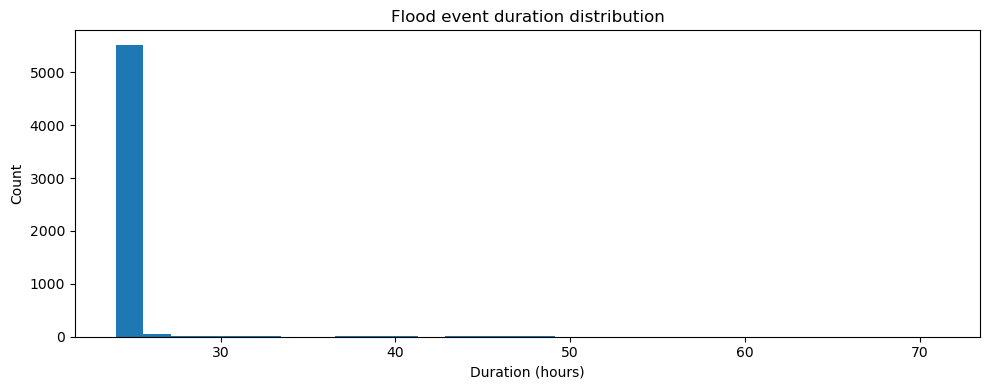

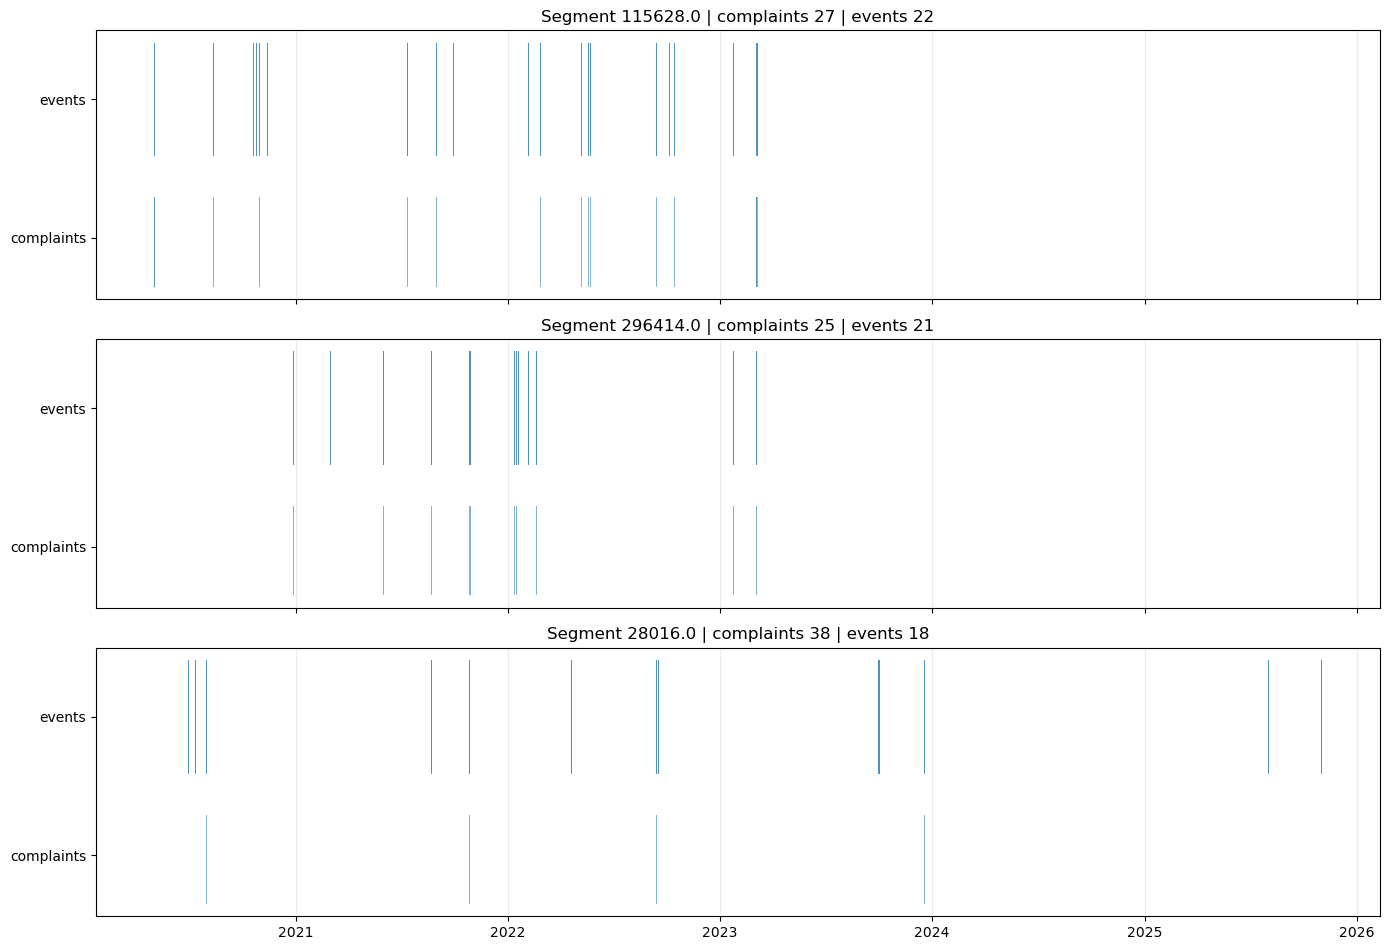

In [13]:
if not closed_events.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(closed_events["duration_hours"].clip(lower=0).dropna(), bins=30)
    ax.set_title("Flood event duration distribution")
    ax.set_xlabel("Duration (hours)")
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()

plot_event_timelines(individual_complaints, flood_events, top_n=3)

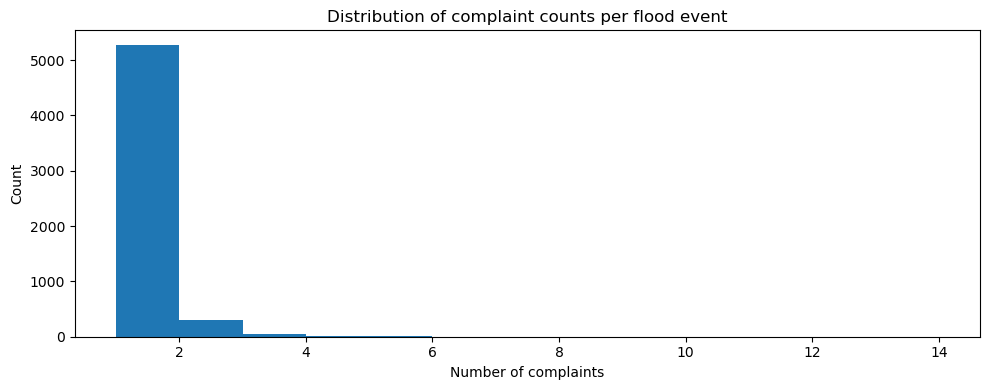

In [14]:
if not flood_events.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    max_complaints = int(flood_events["n_complaints"].max())
    ax.hist(flood_events["n_complaints"], bins=range(1, max_complaints + 2))
    ax.set_title("Distribution of complaint counts per flood event")
    ax.set_xlabel("Number of complaints")
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()

## Final output contract

The final CSV files are written to:

- `data/processed/311/individual_complaints.csv`
- `data/processed/311/flood_events.csv`

The final event table uses exactly these core columns:

- `event_id`
- `start`
- `end`
- `segment_id`
- `n_complaints`
- `status`

The complaint table uses `segment_id` as the main spatial identifier. Street-name normalization is used only as fallback after coordinate-based nearest-segment matching.

flood_events

In [15]:
flood_events['end'].isna().sum()

np.int64(0)

In [16]:
flood_events

,event_id,start,end,duration_hours,segment_id,n_complaints,status
0,1,2022-12-23 13:08:00+00:00,2022-12-24 13:08:00+00:00,24.00,103598.0,1,0
1,2,2025-12-19 13:20:00+00:00,2025-12-20 13:20:00+00:00,24.00,103617.0,1,0
2,3,2022-12-25 03:08:00+00:00,2022-12-26 03:08:00+00:00,24.00,105790.0,1,0
3,4,2023-04-30 22:11:00+00:00,2023-05-01 22:11:00+00:00,24.00,105803.0,1,0
4,5,2023-09-29 15:47:00+00:00,2023-09-30 15:53:00+00:00,24.10,105803.0,2,0
...,...,...,...,...,...,...,...
5665,5666,2022-02-25 15:42:00+00:00,2022-02-26 15:42:00+00:00,24.00,9009979.0,1,0
5666,5667,2022-05-07 15:59:00+00:00,2022-05-08 15:59:00+00:00,24.00,9009979.0,1,0
5667,5668,2024-08-07 02:47:00+00:00,2024-08-08 02:47:00+00:00,24.00,9009979.0,1,0
5668,5669,2026-03-05 18:23:00+00:00,2026-03-06 23:14:00+00:00,28.85,9009979.0,2,0
